# `detectorsim2d` — particle event simulation

`detectorsim2d` builds on `detector2d`'s geometry to generate whole events:
particles fly from a vertex through a magnetic field, cross tracker layers
(position hits), and shower/deposit energy in calorimeters or leave MIP
trails, depending on species. The physics content is one table — **the
three interaction classes stop in three different places**, which is the
only reason a detector can tell them apart at all:

| species | tracker | ECAL | HCAL | muon system |
|---|---|---|---|---|
| `electron`, `positron` | hits | shower, absorbed | -- | -- |
| `photon`, `pi0` | -- (neutral) | shower, absorbed | -- | -- |
| `pi+`, `pi-` | hits | MIP trail | shower, absorbed | -- |
| `neutron` | -- (neutral) | -- | shower, absorbed | -- |
| `mu+`, `mu-` | hits | MIP trail | MIP trail | hits |


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from detector2d.geometry import LineLayer
from detectorsim2d.config import SimConfig, ParticleGunConfig, FieldConfig, load_config
from detectorsim2d.simulate import simulate_events
from detectorsim2d.vis import plot_event, plot_lego
from detectorsim2d.response import sum_cells
from detectorsim2d.io import write_run, read_run, read_deposits


## A minimal, hand-built detector

`SimConfig` can be built entirely in Python — no YAML required — for a
single line layer and a constant field. `simulate_events` returns a
**3-tuple**: `(particles, hits, deposits)`.


In [2]:
config = SimConfig(
    layers=[LineLayer(layer_id=0, p1=(10.0, -50.0), p2=(10.0, 50.0))],
    magnetic_field=FieldConfig(bz=1.0),
    gun=ParticleGunConfig(n_particles=5),
    n_events=20,
    seed=1,
)
particles, hits, deposits = simulate_events(config)
print("particles:", particles.shape, "hits:", hits.shape, "deposits:", deposits.shape)
particles.head()


particles: (100, 10) hits: (76, 9) deposits: (0, 9)


,event_id,particle_id,species,pdg,x0,y0,phi0,charge,energy,radius
0,0,0,NaN,NaN,0.0,0.0,0.007093,-1.0,9.554173,-31.868490
1,0,1,NaN,NaN,0.0,0.0,0.269190,-1.0,3.806483,-12.696741
2,0,2,NaN,NaN,0.0,0.0,-0.046004,-1.0,8.449323,-28.183200
3,0,3,NaN,NaN,0.0,0.0,0.029756,-1.0,1.248032,-4.162882
4,0,4,NaN,NaN,0.0,0.0,0.152108,1.0,5.843290,19.490626


No `species:` was given to the gun, so every particle is a "bare charged
stub" (no species/pdg, charge drawn uniformly from `charges`) — this is why
`deposits` above is empty even though the config has no calorimeter at all.


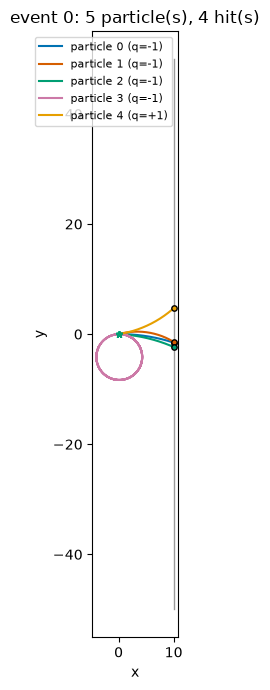

In [3]:
fig = plot_event(particles, hits, config.layers, event_id=0)


## The full detector: tracker + ECAL + HCAL + muon system

`configs/full_detector.yaml` ships the whole detector — 6 barrel tracker
layers, a 3-layer ECAL, a 2-layer HCAL, and a 3-station octagonal muon
system — with a piecewise field (strong in the tracker, none in the calos,
reversed in the muon return yoke) and a gun that actually draws particle
`species`.


In [4]:
full_config = load_config("../aihep/simulator/detectorsim2d/configs/full_detector.yaml")
rng = np.random.default_rng(42)
particles, hits, deposits = simulate_events(full_config, rng=rng)
print("particles:", particles.shape, "hits:", hits.shape, "deposits:", deposits.shape)
particles[["particle_id", "species", "charge", "energy"]]


particles: (8, 10) hits: (72, 9) deposits: (144, 9)


,particle_id,species,charge,energy
0,0,pi0,0.0,142.885963
1,1,mu+,1.0,46.369657
2,2,neutron,0.0,233.119117
3,3,mu+,1.0,146.108063
4,4,mu+,1.0,279.494197
5,5,pi-,-1.0,144.155976
6,6,mu+,1.0,175.283740
7,7,electron,-1.0,196.866032


`full_config` has a **piecewise** field (`full_config.field_regions`): strong
in the tracker, none in the calorimeters, reversed in the muon system. Pass
`field=full_config.field_regions` (plus `world_radius`/`max_path_length`, so
a low-`pt` particle's path terminates instead of circling forever) to
`plot_event` so it draws each particle's *actual* multi-segment path through
that field, not the single constant-field arc implied by its stored
`radius`. `hits`/`deposits` are already computed correctly either way —
`simulate_events` always uses the real piecewise field internally — this
only affects how the connecting trajectory *line* is drawn between them:
without `field=`, tracks that should bend one way in the tracker, go
straight through the calorimeters, and bend the other way in the muon
system are instead drawn as one single wrong-radius spiral.


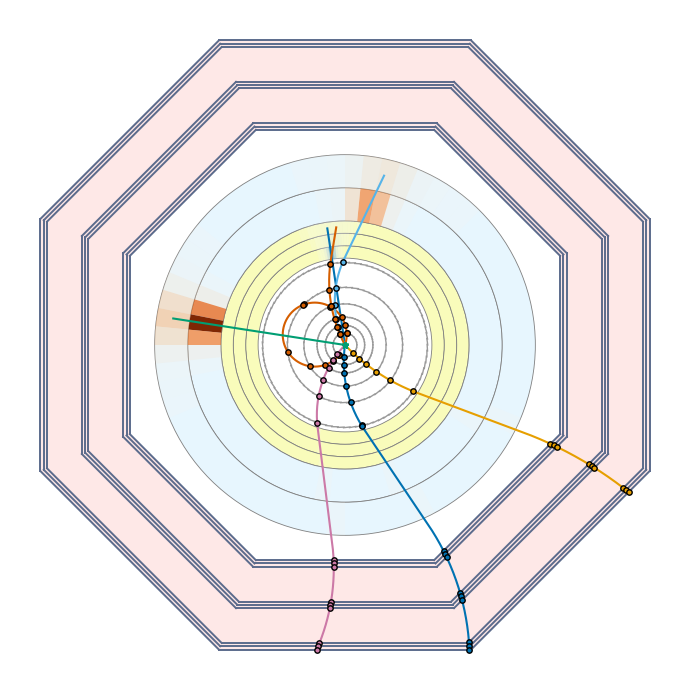

In [5]:
from viz_style import PRINT, PRESENT, use_theme
with use_theme(PRESENT):
    fig = plot_event(
        particles, hits, full_config.layers, event_id=0, deposits=deposits,
        field=full_config.field_regions, world_radius=full_config.world_radius,
        max_path_length=full_config.max_path_length,
    )


### Per-particle energy deposits

`deposits` is **truth-level**: one row per `(particle, cell)`, so two
overlapping showers each get their own row in the same cell. Grouping by
`system` shows exactly the stopping-point table above, straight from data.


In [6]:
for _, particle in particles[particles["event_id"] == 0].iterrows():
    mine = deposits[deposits["particle_id"] == particle["particle_id"]]
    by_system = mine.groupby("system")["energy"].sum().to_dict()
    print(f"{particle['species']:>10s}  charge={particle['charge']:+.0f}  deposits={by_system}")


       pi0  charge=+0  deposits={'ecal': 142.7903267395694}
       mu+  charge=+1  deposits={}
   neutron  charge=+0  deposits={'hcal': 230.2335124935801}
       mu+  charge=+1  deposits={'ecal': 0.929884821719656, 'hcal': 1.977248644983983}
       mu+  charge=+1  deposits={'ecal': 0.9669859131410399, 'hcal': 1.511544144604432}
       pi-  charge=-1  deposits={'ecal': 0.9095779344327173, 'hcal': 142.4761338993978}
       mu+  charge=+1  deposits={'ecal': 0.9340080241563222, 'hcal': 1.756009180274342}
  electron  charge=-1  deposits={'ecal': 197.85937425802766}


Note the `mu+` and `neutron`/`pi0`/`electron` rows: muons leave a small,
energy-independent MIP trail in *both* calorimeters and still reach the muon
system; a `photon`/`pi0` (neutral, no tracker hits) fully showers in the
ECAL; a neutron passes both the tracker and ECAL invisibly and only showers
in the HCAL.

`detectorsim2d.response.sum_cells` collapses the truth-level `deposits`
table to the particle-blind, per-cell view a real reconstruction would
actually see (cells shared by two particles become one summed row):


In [7]:
summed = sum_cells(deposits)
print(f"{len(deposits)} truth deposit rows -> {len(summed)} reconstructed cells")
summed.head()


144 truth deposit rows -> 103 reconstructed cells


,event_id,system,layer_id,cell_id,x,y,s_local,energy
0,0,ecal,100,62,8.281625,224.847537,345.145677,0.361836
1,0,ecal,100,64,-2.761096,224.983058,356.190339,0.094327
2,0,ecal,100,65,-8.281625,224.847537,361.712670,0.932975
3,0,ecal,100,66,-13.797166,224.576575,367.235001,4.781609
4,0,ecal,100,67,-19.304395,224.170338,372.757331,16.056485


### The calorimeter unrolled in azimuth (`plot_lego`)

One row per sampling layer, showing the longitudinal profile and lateral
spread of each shower at a glance.


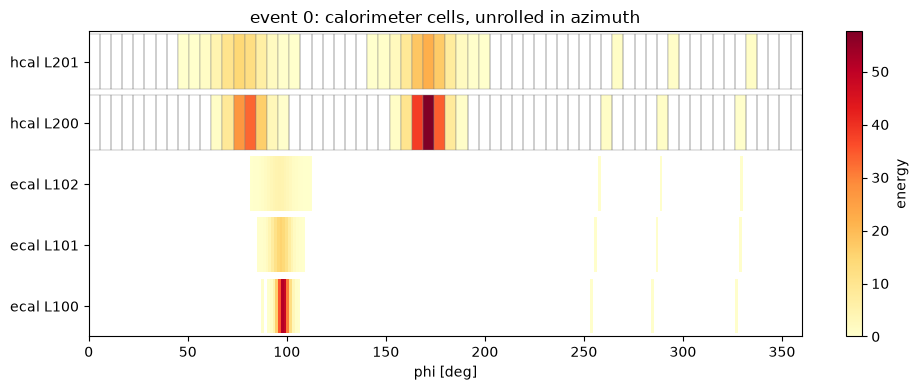

In [8]:
fig = plot_lego(deposits, full_config.layers, event_id=0)


## Event topologies: jet and anomaly gun modes

Every gun so far has drawn each particle's direction independently
and uniformly (`gun.mode`'s default, `"standard"`). `gun.mode` swaps
that for a different *event topology*, on top of whatever
species/pt/vertex sampling the gun already does:

| mode | what changes |
|---|---|
| `standard` | every particle's `phi0` drawn independently and uniformly -- the original behavior |
| `jets` | same multiplicity, but particles are grouped around 2-4 jet axes with a Gaussian angular spread -- collimated sprays instead of a uniform one. A fraction of jets (`b_jet_fraction`, default 15%) are "b-jets": their vertex is displaced along the jet axis, standing in for an invisible parent decaying in flight |
| `anomaly` | samples exactly like `standard`, then -- with probability `anomaly_rate` per event -- overlays an injected, unphysical cluster: two high-energy calorimeter showers back-to-back with a mu+ mu- pair along the same axis |

`configs/jets.yaml` and `configs/anomaly.yaml` are `full_detector.yaml`
with the gun switched into each mode.

In [9]:
from detectorsim2d import GUN_MODES

print("gun modes:", GUN_MODES)


gun modes: ('standard', 'jets', 'anomaly')


### `jets` mode

`jet_count_min`/`jet_count_max` draw 2-4 jet axes per event; each of
the gun's `n_particles` is assigned to one axis and offset from it by
`jet_cone_sigma` (radians) of Gaussian jitter. Species, pt, and vertex
are still drawn exactly as `standard` would -- only the direction
changes.

Each jet axis, independently, has probability `b_jet_fraction` (default
0.15, and what `configs/jets.yaml` sets) of being a **b-jet**: instead of
starting at the primary vertex, *all* of that jet's particles share one
vertex displaced along the jet's own axis by a flight length drawn
uniformly from `[b_jet_decay_length_min, b_jet_decay_length_max]` --
standing in for an invisible parent (e.g. a B hadron) that travels some
distance through the tracker before decaying into the visible jet. No flag
marks which jets these are; the displaced `(x0, y0)` is the only tell, same
as `anomaly` mode's injected cluster below.

In [10]:
jets_config = load_config("../aihep/simulator/detectorsim2d/configs/jets.yaml")
rng = np.random.default_rng(42)
particles_jets, hits_jets, deposits_jets = simulate_events(jets_config, rng=rng)
print("mode:", jets_config.gun.mode, "particles:", particles_jets.shape)
particles_jets[particles_jets["event_id"] == 0][["particle_id", "species", "phi0"]].sort_values("phi0")


mode: jets particles: (50, 10)


,particle_id,species,phi0
35,35,pi-,-0.556770
22,22,pi-,-0.511606
41,41,photon,-0.502914
49,49,pi+,-0.487603
31,31,pi0,-0.483762
34,34,electron,-0.479040
18,18,pi-,-0.470621
3,3,neutron,-0.469967
1,1,positron,-0.469342
9,9,pi-,-0.465415


Sorted by `phi0`, the particles fall into a handful of tight clusters
rather than spreading evenly across the full range -- the same gun,
aimed differently. Plotting the event shows it directly: collimated
sprays instead of the uniform spray of the `full_config` event above.

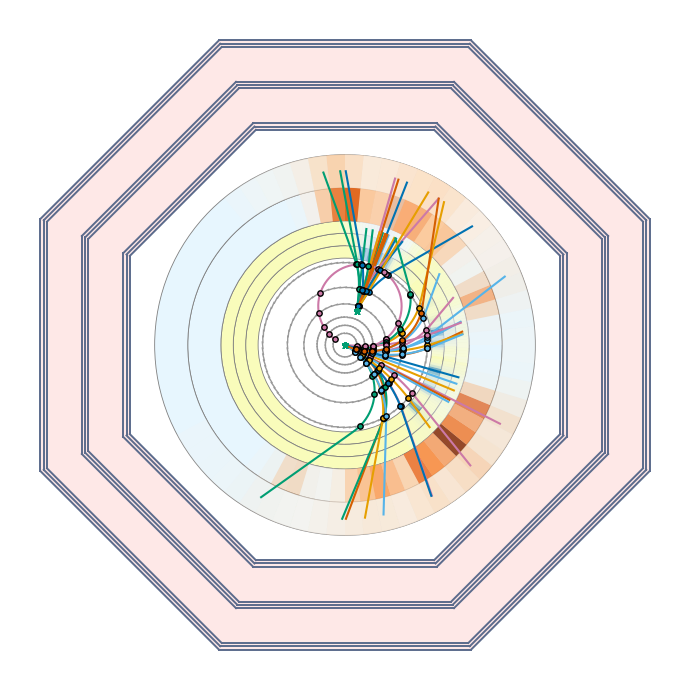

In [11]:
with use_theme(PRESENT):
    fig = plot_event(
        particles_jets, hits_jets, jets_config.layers, event_id=0, deposits=deposits_jets,
        field=jets_config.field_regions, world_radius=jets_config.world_radius,
        max_path_length=jets_config.max_path_length,
    )


### Spotting the b-jet

Grouping this same event's particles by their own `(x0, y0)` recovers each
jet's vertex directly -- one row per distinct vertex, most at the primary
vertex `(0, 0)`, any others displaced along their jet's axis:

In [12]:
event0 = particles_jets[particles_jets["event_id"] == 0]
vertices = event0[["x0", "y0"]].drop_duplicates().copy()
vertices["distance_from_origin"] = np.hypot(vertices["x0"], vertices["y0"])
vertices["n_particles"] = [len(event0[(event0["x0"] == x) & (event0["y0"] == y)]) for x, y in zip(vertices["x0"], vertices["y0"])]
vertices.sort_values("distance_from_origin", ascending=False)

,x0,y0,distance_from_origin,n_particles
0,28.590012,83.278907,88.049788,23
1,0.000000,0.000000,0.000000,27


Zooming the same figure into the tracker region makes the displaced vertex
directly visible: one cluster of vertex stars sits exactly at the origin,
another sits off to the side -- the jet whose "invisible parent" decayed a
few tracker layers out instead of at the primary vertex.

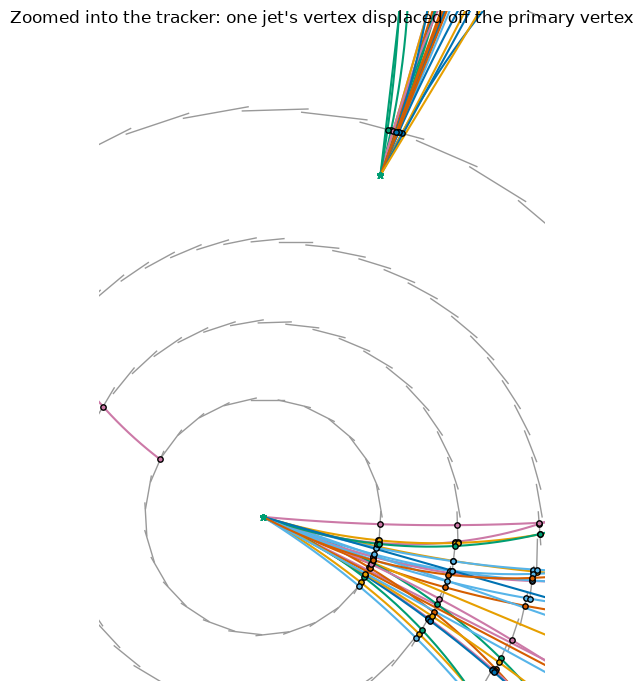

In [13]:
margin = 40.0
x_span = (min(0.0, vertices["x0"].min()) - margin, max(0.0, vertices["x0"].max()) + margin)
y_span = (min(0.0, vertices["y0"].min()) - margin, max(0.0, vertices["y0"].max()) + margin)

ax = fig.axes[0]
ax.set_xlim(*x_span)
ax.set_ylim(*y_span)
fig.suptitle("Zoomed into the tracker: one jet's vertex displaced off the primary vertex")
fig

### `anomaly` mode

`anomaly_rate` is a per-event coin flip; on a hit, four extra
particles are injected from one shared vertex: two
`anomaly_calo_species` showers lined up back-to-back (`axis` and
`axis + pi`), plus a `mu+`/`mu-` pair collinear with them. Energies are
set as multiples of `pt_max` (`anomaly_calo_scale`, `anomaly_muon_scale`)
so the cluster reads as "high energetic" whatever a config's own
`pt_min`/`pt_max` are tuned to -- a planted signal for exercising
anomaly-detection algorithms, not a physical process.

`configs/anomaly.yaml` runs 10 events at `anomaly_rate: 0.5` so a run
has a decent chance of containing a few. There's no `is_anomaly` flag
on `particles` -- finding the injected events is part of the exercise
-- but the simplest possible tell is already visible from the particle
count alone, since the cluster adds exactly 4 rows to an event's
otherwise-fixed `n_particles`:

In [14]:
anomaly_config = load_config("../aihep/simulator/detectorsim2d/configs/anomaly.yaml")
rng = np.random.default_rng(42)
particles_anomaly, hits_anomaly, deposits_anomaly = simulate_events(anomaly_config, rng=rng)

counts_per_event = particles_anomaly.groupby("event_id").size()
anomalous_events = counts_per_event[counts_per_event > anomaly_config.gun.n_particles].index.tolist()
print(f"{len(anomalous_events)}/{anomaly_config.n_events} events got the injected cluster:", anomalous_events)


4/10 events got the injected cluster: [2, 5, 6, 7]


In [15]:
anomalous_event_id = anomalous_events[0]
event = particles_anomaly[particles_anomaly["event_id"] == anomalous_event_id]
event[["particle_id", "species", "charge", "energy", "phi0"]].sort_values("energy", ascending=False)


,particle_id,species,charge,energy,phi0
8,4,mu+,1.0,450.000000,2.058567
9,5,mu-,-1.0,450.000000,5.200160
4,0,pi0,0.0,261.007555,0.903930
5,1,pi0,0.0,202.008653,-1.713808
6,2,photon,0.0,0.060000,2.058567
7,3,photon,0.0,0.060000,5.200160


The two `photon`s and the `mu+`/`mu-` sit at the top by energy, and
their `phi0` come in two values exactly `pi` apart -- the back-to-back
pair the table above describes, sitting on top of an otherwise
ordinary `standard` event. Plotting it shows the same thing spatially:
two showers on opposite sides of the detector, each with a muon
riding straight through it into the muon system.

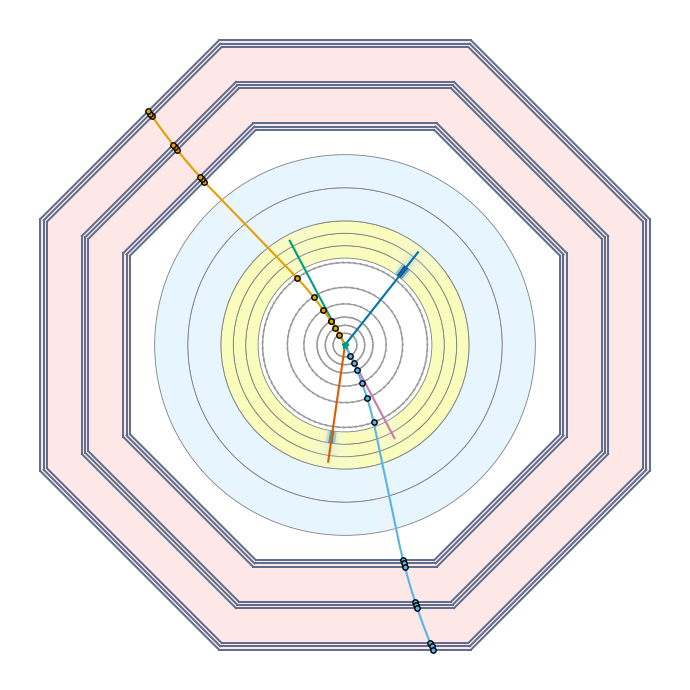

In [16]:
with use_theme(PRESENT):
    fig = plot_event(
        particles_anomaly, hits_anomaly, anomaly_config.layers, event_id=anomalous_event_id,
        deposits=deposits_anomaly, field=anomaly_config.field_regions,
        world_radius=anomaly_config.world_radius, max_path_length=anomaly_config.max_path_length,
    )


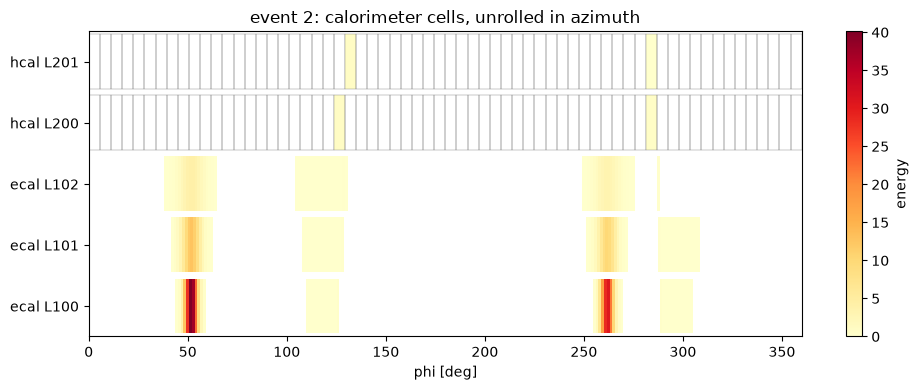

In [17]:
fig = plot_lego(deposits_anomaly, anomaly_config.layers, event_id=anomalous_event_id)


Unrolled in azimuth, the two injected showers are the tallest peaks in
the ECAL rows, 180 degrees apart -- exactly the "lined up" cluster
`anomaly_axis_jitter: 0.0` promises, and visually distinct from the
softer, scattered deposits the rest of the event's `standard`-sampled
particles leave behind.

## IO round-trip

`write_run`/`read_run` store `particles`/`hits` as CSV or Arrow;
`io.read_run` deliberately stays a **2-tuple** (`tracking/graphs` unpacks
exactly two values from it) — `deposits` is written/read separately via the
optional fourth argument / `read_deposits`.


In [18]:
import tempfile

with tempfile.TemporaryDirectory() as run_dir:
    write_run(run_dir, "arrow", particles, hits, deposits)
    particles_back, hits_back = read_run(run_dir, "arrow")
    deposits_back = read_deposits(run_dir, "arrow")

print(particles_back.shape, hits_back.shape, deposits_back.shape)


(8, 10) (72, 9) (144, 9)


## Gotchas recap

- Neutral particles (`photon`, `pi0`, `neutron`) leave **zero tracker
  hits** — a real behavior change from the pre-calorimeter version of this
  package, not a bug.
- `configs/default.yaml`'s gun has no `species:`, so simulating with it
  never populates `deposits` even against a layout with a calorimeter — add
  `species:` to the gun config (or build `ParticleGunConfig(species=...)`
  directly) to exercise the calorimeter.
- Low-`pt` particles can circle forever in the tracker unless
  `tracker_boundary`/`world_radius`/`max_path_length` are set —
  `full_detector.yaml`'s own gun (`pt_min: 20`) deliberately leaves some
  particles doing exactly this.
- `io.read_run` always returns exactly `(particles, hits)`; fetch `deposits`
  separately with `read_deposits`.
